In [1]:
%pip install scikit-image cellpose matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [10]:
# 1. Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from skimage import io
from cellpose import models, core
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import closing, disk

# Check if GPU is available for Cellpose
use_GPU = core.use_gpu()
print(f"GPU available: {use_GPU}")

GPU available: False


Success! Loaded 55 images, 55 cell masks, and 55 nuclei masks.


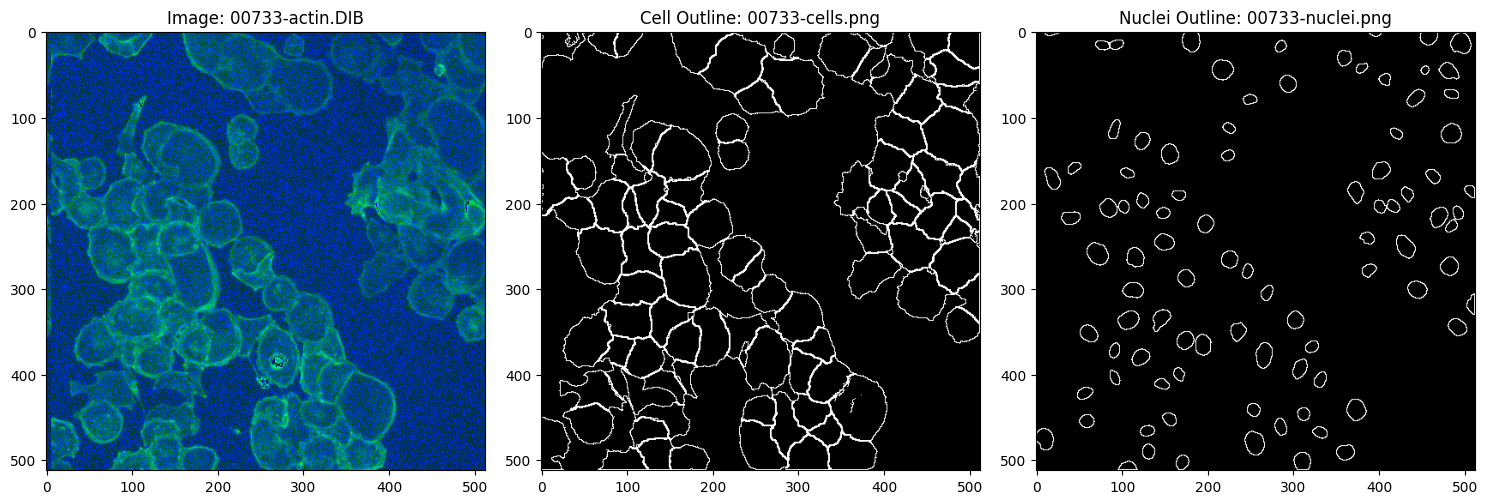

In [3]:
# File paths
image_dir = "C:/Users/Lola/OneDrive/Desktop/BBBC018/BBBC018_v1_images"
mask_dir = "C:/Users/Lola/OneDrive/Desktop/BBBC018/BBBC018_v1_outlines"

# Filter files
image_files = sorted([f for f in os.listdir(image_dir) if 'actin' in f.lower() and f.endswith('.DIB')])
cell_outline_files = sorted([f for f in os.listdir(mask_dir) if 'cells' in f.lower() and f.endswith('.png')])
nuclei_outline_files = sorted([f for f in os.listdir(mask_dir) if 'nuclei' in f.lower() and f.endswith('.png')])

# Sanity check
if not image_files or not cell_outline_files or not nuclei_outline_files:
    print("Error: Missing files! Check your folders for .DIB and .png files.")
else:
    # Read the files
    images = [io.imread(os.path.join(image_dir, f)) for f in image_files]
    cell_masks = [io.imread(os.path.join(mask_dir, f)) for f in cell_outline_files]
    nuclei_masks = [io.imread(os.path.join(mask_dir, f)) for f in nuclei_outline_files]
    
    # Check for matching counts
    if len(images) == len(cell_masks) == len(nuclei_masks):
        print(f"Success! Loaded {len(images)} images, {len(cell_masks)} cell masks, and {len(nuclei_masks)} nuclei masks.")
        
        # Flip images vertically to match the mask coordinate system
        images = [np.flipud(img) for img in images]

        # Show the first triplet to verify
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(images[0], cmap='gray')
        plt.title(f"Image: {image_files[0]}")
        
        plt.subplot(1, 3, 2)
        plt.imshow(cell_masks[0], cmap='gray')
        plt.title(f"Cell Outline: {cell_outline_files[0]}")
        
        plt.subplot(1, 3, 3)
        plt.imshow(nuclei_masks[0], cmap='gray')
        plt.title(f"Nuclei Outline: {nuclei_outline_files[0]}")
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: Counts don't match! Images: {len(images)}, Cells: {len(cell_masks)}, Nuclei: {len(nuclei_masks)}")

Created 55 Seeded Ground Truth Label Maps.


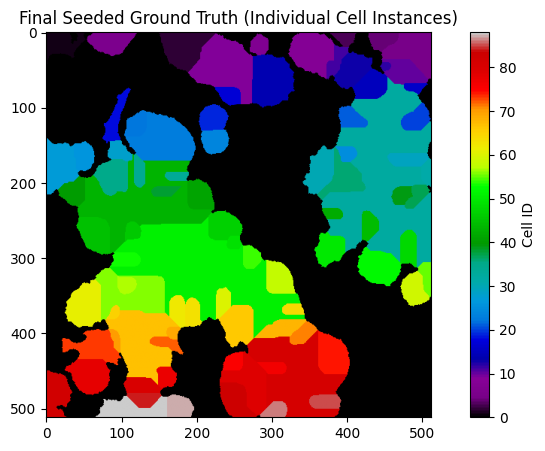

In [9]:
def seeded_watershed(actin_outline, nuclei_outline):
    # 1. Fill the nuclei outlines to create solid "seeds"
    filled_nuclei = ndi.binary_fill_holes(nuclei_outline > 0)
    markers, _ = ndi.label(filled_nuclei) 
    
    # 2. Fill the actin outlines to create the total "cell area"
    actin_sealed = closing(actin_outline > 0, disk(1))
    filled_actin = ndi.binary_fill_holes(actin_sealed)
    
    # 3. Distance transform helps the watershed 'flow' from center to edge
    distance = ndi.distance_transform_edt(filled_actin)
    
    # 4. Watershed: Grow the markers (nuclei) until they fill the actin area
    labels = watershed(-distance, markers, mask=filled_actin)
    
    return labels

# Process all 55 samples
final_gt_labels = []
for a, n in zip(cell_masks, nuclei_masks):
    final_gt_labels.append(seeded_watershed(a, n))

print(f"Created {len(final_gt_labels)} Seeded Ground Truth Label Maps.")

# Visual check of the first sample
plt.figure(figsize=(10, 5))
plt.imshow(final_gt_labels[0], cmap='nipy_spectral')
plt.title("Final Seeded Ground Truth (Individual Cell Instances)")
plt.colorbar(label="Cell ID")
plt.show()

In [ ]:
# 3. Running Cellpose v4.0.1+ (Ultra-Compatible version)
# Let's try to initialize the high-level Cellpose class directly
try:
    from cellpose.models import Cellpose
    model = Cellpose(gpu=False, model_type='cyto3')
except:
    model = models.CellposeModel(gpu=False, model_type='cyto3')

cp_masks = []
print(f"Starting inference on {len(images)} images...")
start_time = time.time()

for i, img in enumerate(images):
    print(f"Processing image {i+1}/{len(images)}...", end="\r")
    
    # We strip ALL extra arguments. Cellpose will use its defaults.
    # We only pass the image and a guessed diameter.
    res = model.eval(img, diameter=30)
    
    # Grab the mask (usually the first item in the returned tuple)
    if isinstance(res, tuple):
        mask = res[0]
    else:
        mask = res
        
    cp_masks.append(mask)

end_time = time.time()
print(f"\n✅ Finished! Total time: {end_time - start_time:.2f} seconds.")

model_type argument is not used in v4.0.1+. Ignoring this argument...


Starting inference on 55 images...


In [ ]:
# 4. Final Benchmarking (IoU)
def calculate_iou(gt, pred):
    intersection = np.logical_and(gt > 0, pred > 0).sum()
    union = np.logical_or(gt > 0, pred > 0).sum()
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

# Run the calculation across all images
iou_scores = [calculate_iou(g, p) for g, p in zip(final_gt_labels, cp_masks)]
mean_iou = np.mean(iou_scores)

print(f"FINAL MEAN IoU: {mean_iou:.4f}")
print(f"Top Score: {np.max(iou_scores):.4f}")
print(f"Lowest Score: {np.min(iou_scores):.4f}")

In [ ]:
# 5. Visual Comparison (Best Performance)
best_idx = np.argmax(iou_scores)

plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.imshow(images[best_idx], cmap='gray')
plt.title(f"Original Image (Sample {best_idx})")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(final_gt_labels[best_idx], cmap='nipy_spectral')
plt.title("Ground Truth (Seeded Watershed)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cp_masks[best_idx], cmap='nipy_spectral')
plt.title(f"Cellpose Prediction (IoU: {iou_scores[best_idx]:.3f})")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 6. Visual Comparison (Worst Performance)
worst_idx = np.argmin(iou_scores)

plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.imshow(images[worst_idx], cmap='gray')
plt.title(f"Original Image (Sample {worst_idx})")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(final_gt_labels[worst_idx], cmap='nipy_spectral')
plt.title("Ground Truth (Seeded Watershed)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cp_masks[worst_idx], cmap='nipy_spectral')
plt.title(f"Cellpose Prediction (IoU: {iou_scores[worst_idx]:.3f})")
plt.axis('off')

plt.tight_layout()
plt.show()